In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from statsmodels.tsa.seasonal import seasonal_decompose

#ignore warnings
warnings.filterwarnings('ignore')

In [ ]:
#load dataset
url='https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv'
stock_data=pd.read_csv(url,parse_dates=['Month'],index_col='Month')

In [ ]:
stock_data

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
...,...
1960-08-01,606
1960-09-01,508
1960-10-01,461


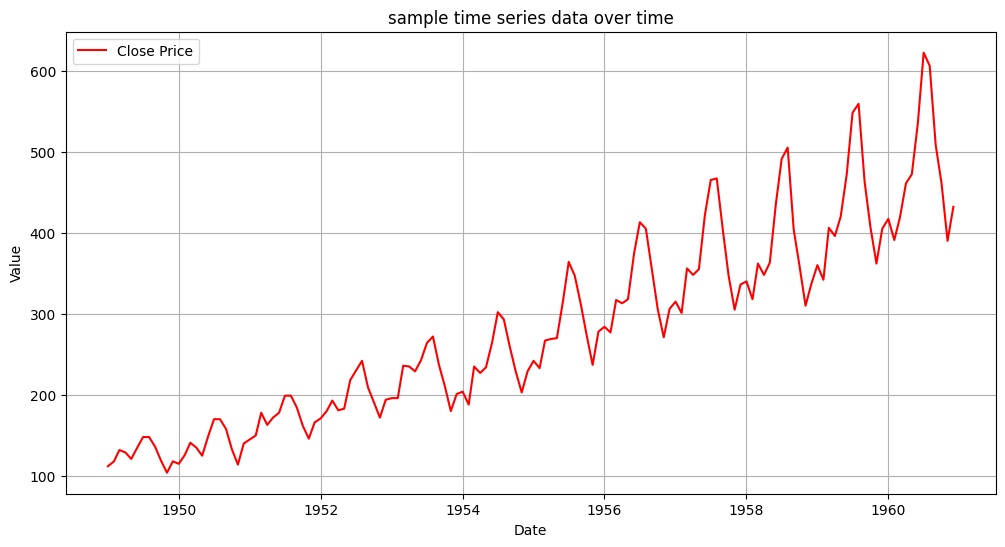

In [ ]:
#plot the time series
plt.figure(figsize=(12,6))
plt.plot(stock_data.index,stock_data['Passengers'],label='Close Price',color='red')
plt.title('sample time series data over time')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

classical time series decomposition

<Figure size 1200x800 with 0 Axes>

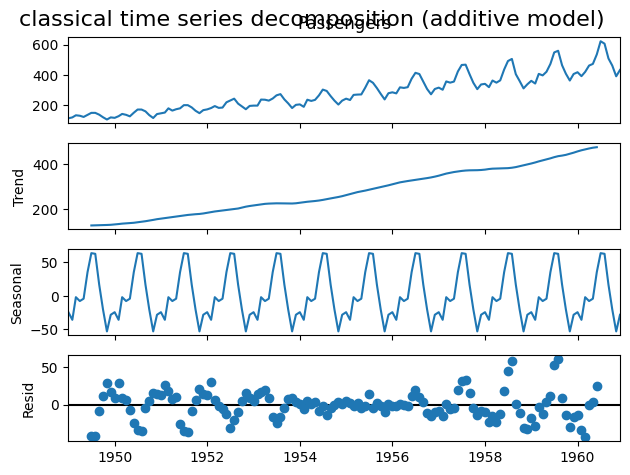

In [ ]:
decomposition_additive=seasonal_decompose(stock_data['Passengers'],model='additive',period=12)

plt.figure(figsize=(12,8))
decomposition_additive.plot()
plt.suptitle('classical time series decomposition (additive model) ',fontsize=16)
plt.show()

STL decomosition using LOESS

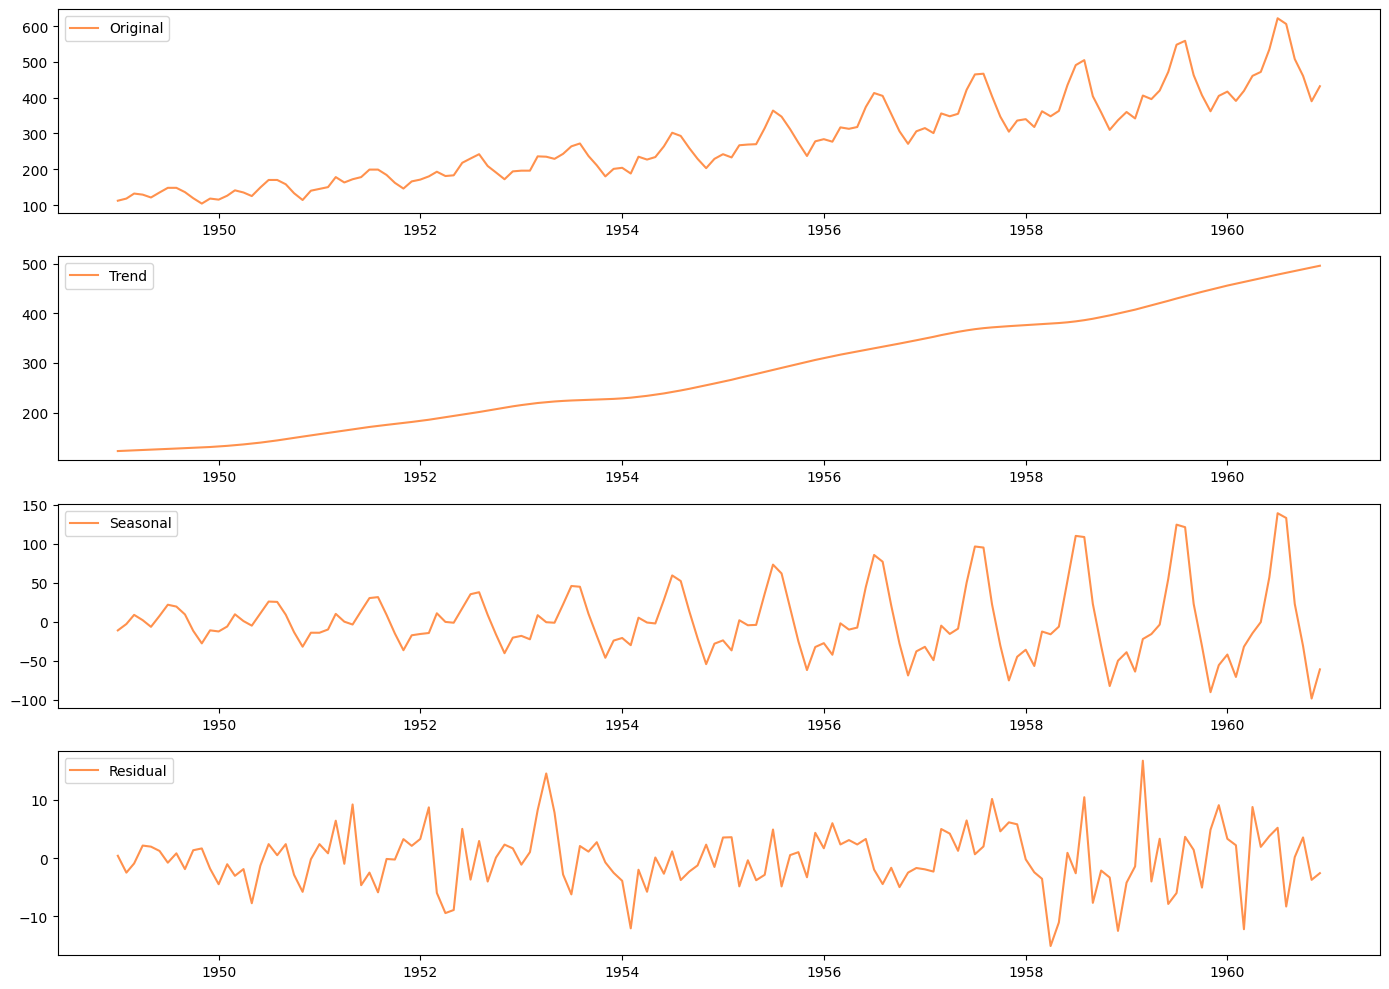

In [ ]:
from statsmodels.tsa.seasonal import STL

stl = STL(stock_data['Passengers'], period= 12)  # Use 12 for monthly seasonality
result = stl.fit()

# Plot the decomposition components
plt.figure(figsize=(14, 10))

plt.subplot(411)
plt.plot(result.observed, label='Original', color='#FF914D')
plt.legend(loc='upper left')

plt.subplot(412)
plt.plot(result.trend, label='Trend', color='#FF914D')
plt.legend(loc='upper left')

plt.subplot(413)
plt.plot(result.seasonal, label='Seasonal', color='#FF914D')
plt.legend(loc='upper left')

plt.subplot(414)
plt.plot(result.resid, label='Residual', color='#FF914D')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

stationarity tests

In [ ]:
from statsmodels.tsa.stattools import adfuller,kpss
#ADF test
#perform the augmented dickey-fuller test
adf_test=adfuller(stock_data['Passengers'])

print('ADF test results:')
print(f'ADF Statistic:{round(adf_test[0],3)}')
print(f'p-value:{round(adf_test[1],3)}')
print('critical values:')
for key,value in adf_test[4].items():
  print(f' {key}:{round(value,3)}')

ADF test results:
ADF Statistic:0.815
p-value:0.992
critical values:
 1%:-3.482
 5%:-2.884
 10%:-2.579


kpss test

In [ ]:
kpss_test=kpss(stock_data['Passengers'],regression='ct')

print('\nkpss test results:')
print(f'KPSS Statistic:{round(kpss_test[0],2)}')
print(f'p-value:{kpss_test[1]}')
print('critical values:')
for key,value in kpss_test[3].items():
  print(f' {key}:{value}')


kpss test results:
KPSS Statistic:0.1
p-value:0.1
critical values:
 10%:0.119
 5%:0.146
 2.5%:0.176
 1%:0.216


ks test

strictly stationarity series-ks statistic: 0.068 p-value: 0.6109101078019121
non strictly stationarity series-ks statistic: 0.184 p-value: 0.00040888636357191906


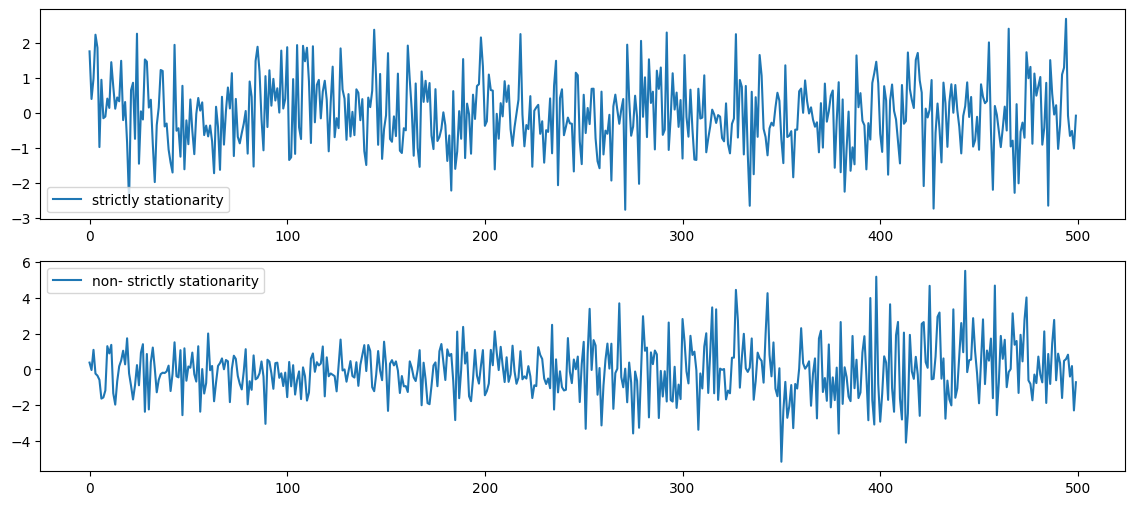

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp

#generating synthetic data for demonstration
np.random.seed(0)
n=500

strict_stationarity_series=np.random.normal(0,1,n)

non_strict_stationarity_series=np.concatenate([np.random.normal(0,1,n//2),np.random.normal(0,2,n//2)])

def ks_test_stationarity(series):
  split=len(series)//2
  series_first_half=series[:split]
  series_second_half=series[split:]
  stat,p_value=ks_2samp(series_first_half,series_second_half)
  return stat,p_value


ks_stat_strict,ks_pvalue_strict=ks_test_stationarity(strict_stationarity_series)
ks_stat_non_strict,ks_pvalue_non_strict=ks_test_stationarity(non_strict_stationarity_series)


print('strictly stationarity series-ks statistic:',ks_stat_strict,'p-value:',ks_pvalue_strict)
print('non strictly stationarity series-ks statistic:',ks_stat_non_strict,'p-value:',ks_pvalue_non_strict)


plt.figure(figsize=(14,6))
plt.subplot(211)
plt.plot(strict_stationarity_series,label='strictly stationarity')
plt.legend()

plt.subplot(212)
plt.plot(non_strict_stationarity_series,label='non- strictly stationarity')
plt.legend()
plt.show()

# AR,MA,ARMA,ARIMA,SARIMA MODELS

In [ ]:
from statsmodels.tsa import ar_model
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

ts_data=stock_data['Passengers']

#AR MODEL
ar_model=sm.tsa.ARIMA(ts_data,order=(2,0,0))
ar_fit=ar_model.fit()
print('\nAR Model Summary:')
print(ar_fit.summary())



AR Model Summary:
                               SARIMAX Results                                
Dep. Variable:             Passengers   No. Observations:                  144
Model:                 ARIMA(2, 0, 0)   Log Likelihood                -702.819
Date:                Tue, 10 Mar 2026   AIC                           1413.639
Time:                        05:51:37   BIC                           1425.518
Sample:                    01-01-1949   HQIC                          1418.466
                         - 12-01-1960                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        280.2991     54.518      5.141      0.000     173.445     387.153
ar.L1          1.2831      0.079     16.316      0.000       1.129       1.437
ar.L2         -0.3322      0.082 

In [ ]:
#MA MODEL
ma_model=sm.tsa.ARIMA(ts_data,order=(0,0,2))
ma_fit=ma_model.fit()
print('\nMA Model Summary:')
print(ma_fit.summary())


MA Model Summary:
                               SARIMAX Results                                
Dep. Variable:             Passengers   No. Observations:                  144
Model:                 ARIMA(0, 0, 2)   Log Likelihood                -757.063
Date:                Tue, 10 Mar 2026   AIC                           1522.126
Time:                        05:51:37   BIC                           1534.005
Sample:                    01-01-1949   HQIC                          1526.953
                         - 12-01-1960                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        280.4095     14.386     19.491      0.000     252.213     308.606
ma.L1          1.3825     23.075      0.060      0.952     -43.844      46.609
ma.L2          1.0000     33.380 

In [ ]:
#ARMA MODEL
arma_model=sm.tsa.ARIMA(ts_data,order=(2,0,2))
arma_fit=arma_model.fit()
print('\nARMA Model Summary:')
print(arma_fit.summary())



ARMA Model Summary:
                               SARIMAX Results                                
Dep. Variable:             Passengers   No. Observations:                  144
Model:                 ARIMA(2, 0, 2)   Log Likelihood                -698.172
Date:                Tue, 10 Mar 2026   AIC                           1408.344
Time:                        05:51:37   BIC                           1426.162
Sample:                    01-01-1949   HQIC                          1415.584
                         - 12-01-1960                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        280.3016     60.094      4.664      0.000     162.519     398.084
ar.L1          0.2540      0.223      1.137      0.256      -0.184       0.692
ar.L2          0.6510      0.19

In [ ]:
#ARIMA MODEL
arima_model=sm.tsa.ARIMA(ts_data,order=(2,1,2))
arima_fit=arima_model.fit()
print('\nARIMA Model Summary:')
print(arima_fit.summary())


ARIMA Model Summary:
                               SARIMAX Results                                
Dep. Variable:             Passengers   No. Observations:                  144
Model:                 ARIMA(2, 1, 2)   Log Likelihood                -671.673
Date:                Tue, 10 Mar 2026   AIC                           1353.347
Time:                        05:51:38   BIC                           1368.161
Sample:                    01-01-1949   HQIC                          1359.366
                         - 12-01-1960                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.6850      0.020     83.060      0.000       1.645       1.725
ar.L2         -0.9548      0.017    -55.420      0.000      -0.989      -0.921
ma.L1         -1.8432      0.1

In [ ]:
#SARIMA MODEL
sarima_model=SARIMAX(ts_data,order=(2,1,2),seasonal_order=(1,1,1,12))
sarima_fit=sarima_model.fit(disp=False)
print('\nSARIMA Model Summary:')
print(sarima_fit.summary())


SARIMA Model Summary:
                                      SARIMAX Results                                       
Dep. Variable:                           Passengers   No. Observations:                  144
Model:             SARIMAX(2, 1, 2)x(1, 1, [1], 12)   Log Likelihood                -503.024
Date:                              Tue, 10 Mar 2026   AIC                           1020.048
Time:                                      05:51:39   BIC                           1040.174
Sample:                                  01-01-1949   HQIC                          1028.226
                                       - 12-01-1960                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4441      0.388      1.145      0.252      -0.316       1.

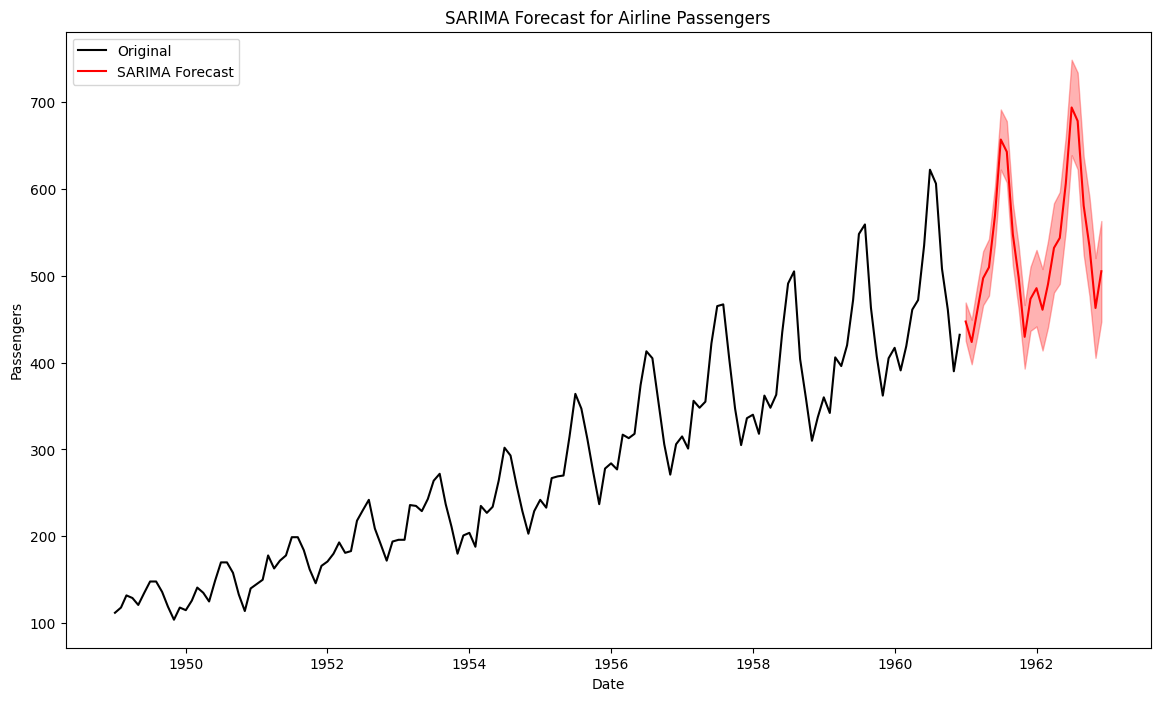

In [ ]:
#plotting forecasts

plt.figure(figsize=(14,8))

#plot original series
plt.plot(ts_data, label="Original", color="black")

#Forecast next 24 months with SARIMA
sarima_forecast = sarima_fit.get_forecast(steps=24)
sarima_conf_int = sarima_forecast.conf_int()

plt.plot(sarima_forecast.predicted_mean, label="SARIMA Forecast", color="red")
plt.fill_between(sarima_conf_int.index,
                 sarima_conf_int.iloc[:,0],
                 sarima_conf_int.iloc[:,1],
                 color="red",alpha=0.3)

plt.title("SARIMA Forecast for Airline Passengers")
plt.xlabel("Date")
plt.ylabel("Passengers")
plt.legend()
plt.show()